Weight học được: [[-9.84395805]
 [ 0.67116988]
 [ 1.05544385]]


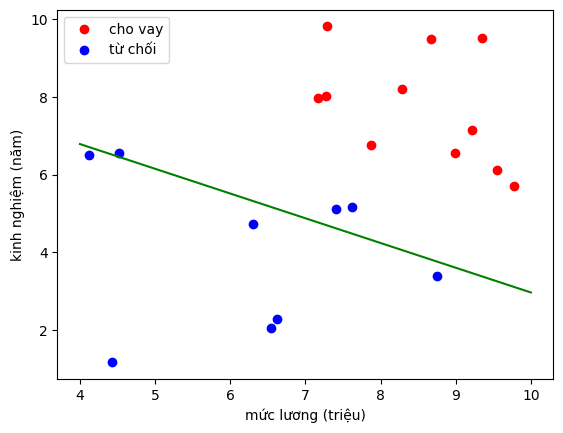

/tmp/ipykernel_55802/1456708493.py:64: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wg[0,0] = model.intercept_


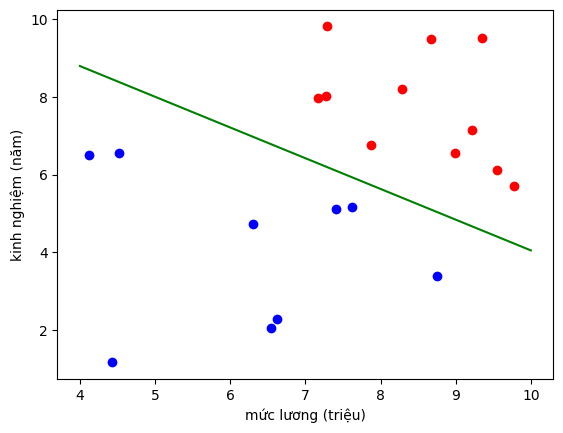

In [1]:
# Logistic Regression demo (tự tạo dataset)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# ===== 1. Tạo dataset giả lập =====
np.random.seed(0)

N = 20
salary = np.random.uniform(4, 10, N)      # mức lương (triệu)
exp = np.random.uniform(1, 10, N)         # kinh nghiệm (năm)

# rule giả lập: lương cao + kinh nghiệm nhiều thì cho vay
y = (salary + 0.8*exp > 12).astype(int)

data = np.column_stack((salary, exp, y))
df = pd.DataFrame(data, columns=["salary","exp","loan"])

x = df[["salary","exp"]].values
y = df["loan"].values.reshape(-1,1)

# ===== 2. Vẽ dữ liệu =====
plt.scatter(x[y[:,0]==1][:,0], x[y[:,0]==1][:,1], c='red', label='cho vay')
plt.scatter(x[y[:,0]==0][:,0], x[y[:,0]==0][:,1], c='blue', label='từ chối')
plt.xlabel("mức lương (triệu)")
plt.ylabel("kinh nghiệm (năm)")
plt.legend()

# ===== 3. Logistic Regression tự cài =====
def sigmoid(z):
    return 1/(1+np.exp(-z))

N = x.shape[0]
X = np.hstack((np.ones((N,1)),x))   # thêm bias

w = np.zeros((3,1))
lr = 0.01
iterations = 1000

for i in range(iterations):
    y_pred = sigmoid(X @ w)
    w = w - lr * (X.T @ (y_pred - y))

print("Weight học được:", w)

# ===== 4. Vẽ đường phân cách =====
x_line = np.array([4,10])
y_line = -(w[0] + w[1]*x_line)/w[2]

plt.plot(x_line, y_line, 'g')
plt.show()

# ===== 5. Lưu và load weight =====
np.save("weight_logistic.npy", w)
w = np.load("weight_logistic.npy")

# ===== 6. Logistic Regression bằng sklearn =====
model = LogisticRegression()
model.fit(x, y.ravel())

wg = np.zeros((3,1))
wg[0,0] = model.intercept_
wg[1:,0] = model.coef_

# vẽ decision boundary sklearn
x_line = np.array([4,10])
y_line = -(wg[0] + wg[1]*x_line)/wg[2]

plt.scatter(x[y[:,0]==1][:,0], x[y[:,0]==1][:,1], c='red')
plt.scatter(x[y[:,0]==0][:,0], x[y[:,0]==0][:,1], c='blue')
plt.plot(x_line, y_line, 'g')
plt.xlabel("mức lương (triệu)")
plt.ylabel("kinh nghiệm (năm)")
plt.show()

# ===== 7. Lưu tham số sklearn =====
np.savez("w_logistic.npz", a=model.intercept_, b=model.coef_)

k = np.load("w_logistic.npz")
model.intercept_ = k["a"]
model.coef_ = k["b"]

### Logistic Regression (phân loại cho vay)

**1. Tạo dữ liệu**
- Dataset gồm 2 đặc trưng:
  - `salary`: mức lương (triệu)
  - `exp`: số năm kinh nghiệm  
- Nhãn `y`:
  - `1`: cho vay
  - `0`: từ chối

---

**2. Hàm sigmoid**

Logistic Regression dùng hàm sigmoid để biến đổi giá trị dự đoán về xác suất:

\[
\sigma(x) = \frac{1}{1 + e^{-x}}
\]

Giá trị đầu ra nằm trong khoảng **0 → 1**.

---

**3. Huấn luyện mô hình**

Các bước chính:

1. Thêm **bias** vào dữ liệu `x`
2. Khởi tạo vector trọng số `w`
3. Lặp nhiều lần:
   - Tính dự đoán `y_pred = sigmoid(Xw)`
   - Cập nhật trọng số bằng **Gradient Descent**

---

**4. Decision boundary**

Sau khi huấn luyện, mô hình tạo ra **đường phân cách** giữa hai lớp:

- vùng **cho vay**
- vùng **từ chối**

Đường này được vẽ trên biểu đồ scatter.

---

**5. Lưu và đọc lại mô hình**

- `np.save()` : lưu trọng số
- `np.load()` : đọc lại trọng số

---

**6. Logistic Regression với sklearn**

Ngoài cách tự cài đặt, có thể dùng thư viện:

```python
from sklearn.linear_model import LogisticRegression